# Binary classification (BENIGN , ATTACK)

In [ ]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

In [2]:
df = pd.read_csv("../data/processed/cicids2017_clean.csv")

In [3]:
# Transformer toutes les attaques en une seule classe
df['Label'] = df['Label'].apply(lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTACK')

In [4]:
print("Distribution des classes après transformation :")
print(df['Label'].value_counts())

Distribution des classes après transformation :
Label
BENIGN    2095057
ATTACK     425741
Name: count, dtype: int64


In [5]:
print(df['Label'].unique())

<ArrowStringArray>
['BENIGN', 'ATTACK']
Length: 2, dtype: str


Encodage + Séparation Train/Test

In [6]:
X = df.drop(columns=['Label'])
y = df['Label']

In [7]:
print(X.shape, y.shape)

(2520798, 69) (2520798,)


In [8]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [9]:
print(encoder.classes_)  # Affiche les classes encodées

['ATTACK' 'BENIGN']


In [10]:
print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

{'ATTACK': np.int64(0), 'BENIGN': np.int64(1)}


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


In [12]:
print(X_train.shape , X_test.shape)

(2016638, 69) (504160, 69)


In [13]:
train_distribution = pd.Series(y_train).value_counts(normalize=True)
test_distribution = pd.Series(y_test).value_counts(normalize=True)
print("Training set distribution:")
print(train_distribution)
print("\nTest set distribution:")
print(test_distribution)

Training set distribution:
1    0.831109
0    0.168891
Name: proportion, dtype: float64

Test set distribution:
1    0.831109
0    0.168891
Name: proportion, dtype: float64


In [14]:
# table of comparison of the models 
results = []

def save_results(model_name, port_version, y_true, y_pred, train_time):
    results.append({
        "Model": model_name,
        "Destination Port": port_version,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Train Time (s)": train_time
    })

Decision tree avec Destination Port :

In [15]:
dt = DecisionTreeClassifier(random_state=42)

In [ ]:
start_time = time.time()

dt.fit(X_train, y_train)

end_time = time.time()

train_time = end_time - start_time

print(f"Training time: {train_time:.2f} seconds")

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [17]:
y_pred = dt.predict(X_test)

In [18]:
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

Decision Tree Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00     85148
      BENIGN       1.00      1.00      1.00    419012

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160



In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Decision Tree with Destination Port Classification Metrics:")

print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1-Score: {f1:.6f}")   

Decision Tree with Destination Port Classification Metrics:
Accuracy: 0.998602
Precision: 0.999155
Recall: 0.999162
F1-Score: 0.999159


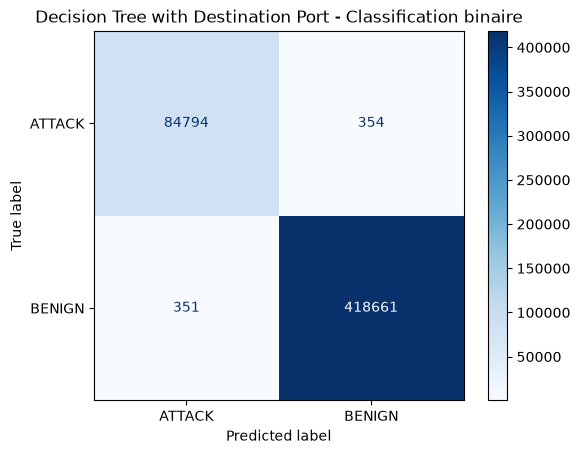

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=encoder.classes_,
    cmap=plt.cm.Blues
    )

plt.title("Decision Tree with Destination Port - Classification binaire")
plt.show()


In [ ]:
# add results to the results list
save_results(
    "Decision Tree",
    "With",
    y_test,
    y_pred,
    train_time
)

NameError: name 'train_time' is not defined

Random Forest avec Destination Port :

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [ ]:
start_time = time.time()

rf.fit(X_train, y_train)

end_time = time.time()

train_time = end_time - start_time

print(f"Training time: {train_time:.2f} seconds")

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
print("Random Forest with Destination Port Classification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

In [ ]:
# metriques 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1-Score: {f1:.6f}")

In [ ]:
# Matrice de confusion pour le modèle Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=encoder.classes_,
    cmap=plt.cm.Blues
)

plt.title("Random Forest (with Destination Port) - Classification binaire")
plt.show()

In [ ]:
# Deboggage 
print(type(rf))

In [ ]:
# append results to the results list
save_results(
    "Random Forest",
    "With",
    y_test,
    y_pred,
    train_time
)

XGBoost with Destination Port :

In [ ]:
# import the library
from xgboost import XGBClassifier

In [ ]:
# Create an XGBoost classifier
xgb = xgboost.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [ ]:
# training the model
start_time = time.time()

xgb.fit(X_train, y_train)

end_time = time.time()

train_time = end_time - start_time

print(f"Training time: {train_time:.2f} seconds")

# predicting the test set results
y_pred = xgb.predict(X_test)

In [ ]:
# Classification Report pour le modèle XGBoost
print("XGBoost Classification Report with Destination Port:")

print(classification_report(y_test, y_pred, target_names=encoder.classes_))

In [ ]:
# metrics of the XGBoost model

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("XGBoost with Destination Port Classification Metrics:")
print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1-Score: {f1:.6f}")

In [ ]:
# Confusion Matrix for the XGBoost model with Destination Port
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=encoder.classes_,
    cmap=plt.cm.Blues
)

In [ ]:
# append results to the results list
save_results(
    "XGBoost",
    "With",
    y_test,
    y_pred,
    train_time
)

Nouveau jeu de donnees :

In [ ]:
X = df.drop(columns=['Label','Destination Port'])  # 'Destination Port' is another column to drop
y = df['Label']

In [ ]:
print(X.shape, y.shape)

In [ ]:
from sklearn.preprocessing import LabelEncoder 

encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

Decision tree sans Destination Port :

In [ ]:
# Creation de modele 
dt = DecisionTreeClassifier(random_state=42)

# entrainement du modele
start_time = time.time()

dt.fit(X_train, y_train)

end_time = time.time()

train_time = end_time - start_time

print(f"Training time: {train_time:.2f} seconds")

# Prediction sur l'ensemble de test
y_pred_dt = dt.predict(X_test)

In [ ]:
# Classification Report pour le modèle Decision Tree
print("Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=encoder.classes_))

In [ ]:
# metriques 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1-Score: {f1:.6f}")


In [ ]:
# matrice de confusion pour le modèle Decision Tree
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    display_labels=encoder.classes_,
    cmap=plt.cm.Blues
)

In [ ]:
# append results to the results list
save_results(
    "Decision Tree",
    "Without",
    y_test,
    y_pred,
    train_time
)

Random Forest Sans Destination Port :

In [ ]:
# Creation du modele

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Entrainement du modele
start_time = time.time()

rf.fit(X_train, y_train)

end_time = time.time()

train_time = end_time - start_time

print(f"Training time: {train_time:.2f} seconds")

# prediction sur l'ensemble de test
y_pred_rf = rf.predict(X_test)

In [ ]:
# Classification Report pour le modèle Random Forest
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=encoder.classes_))

In [ ]:
# metriques 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1-Score: {f1:.6f}")

In [ ]:
# Confusion Matrix pour le modele Random Forest

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=encoder.classes_,
    cmap=plt.cm.Blues
)

In [ ]:
# random forest list of results
save_results(
    "Random Forest",
    "Without",
    y_test,
    y_pred,
    train_time
)

XGBoost without Destination Port:

In [ ]:
# Import the XGBClassifier from xgboost
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

In [ ]:
# Creation du modele XGBoost
xgb = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

In [ ]:
start_time = time.time()

xgb.fit(X_train, y_train)

end_time = time.time()

train_time = end_time - start_time

print(f"Training time: {train_time:.2f} seconds")

In [ ]:
# Prediction sur l'ensemble de test
y_pred_xgb = xgb.predict(X_test)

In [ ]:
# Affichage du rapport de classification pour le modèle XGBoost
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=encoder.classes_))

In [ ]:
# metriques
accuracy = accuracy_score(y_test, y_pred_rf)    
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1-Score: {f1:.6f}")

In [ ]:
# Matrice de confusion pour le modèle XGBoost
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=encoder.classes_,
    cmap=plt.cm.Blues
)

In [ ]:
# append results to the results list
save_results(
    "XGBoost",
    "Without",
    y_test,
    y_pred,
    train_time
)

Comparing the results :

In [ ]:
# comparison des performances des trois modèles avec et sans la colonne "Destination Port"
comparison_df = pd.DataFrame(results)
comparison_df